In [1]:
import os
import fnmatch
import pandas as pd
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import warnings
from tensorflow.keras.callbacks import ReduceLROnPlateau
warnings.filterwarnings('ignore')

In [2]:
# This is my local dir. change to yours :)
dir_path = '/Users/khangdao/Desktop/Project DS/Random_series'

# List all folders in the directory
path_list = [f.path for f in os.scandir(dir_path) if f.is_dir()]

# Print the list of folders
# print(path_list)

images = []
for path in path_list:
    # path = './Random_series_001'
    data = pd.read_csv(f'{path}/image_data.csv')
    df = pd.DataFrame(data)
    boundary = pd.DataFrame()
    df = df.drop(['BaS', 'Sn2BaS3', 'SnS', 'BaS_thickness_cm', 'Sn2BaS3_thickness_cm', 'SnS_thickness_cm'], axis=1)

    # Find the .tif file named Filtered_R_Image in the same directory
    for file in os.listdir(path):
        if file == "Filtered_t_Image.tif":
            # Open the .tif file
            image = Image.open(os.path.join(path, file))
            # Append the image to the images list
            images.append(image)

    with open(f'{path}/settings.json', 'r') as f:
        settings = json.load(f)
    
    boundary1 = settings['boundaries'][1]
    boundary2 = settings['boundaries'][2]
    if 'boundaries' in settings and len(settings['boundaries']) > 2:
        boundary = pd.DataFrame({
        'boundary1': [boundary1],
        'boundary2': [boundary2]
    })
    else:
        raise ValueError("Settings do not contain valid boundaries.")
    df['target'] = df['F'].apply(lambda x: 1 if x < boundary1 else 2 if boundary1 <= x <= boundary2 else 3)

    boundary.to_csv(f'{path}/boundary.csv', index=False)
    df.to_csv(f'{path}/image_data_1.csv', index=False)

print(df.head())
print(settings['boundaries'])

##########################################
# TRAIN - VAL - TEST (Local setup)
##########################################

# path_list = []
# for root, dirs, files in os.walk('./'):
#     # print(root)
#     if len(root)>2:
#         path_list.append(root)

train_directories = path_list[:100]
val_directories = path_list[100:150]
test_directories = path_list[150:]

print(train_directories)
print(val_directories)
print(test_directories)

      x     y            Sn            Ba         F  target
0 -2.49 -0.49  4.323034e-07  2.444360e-07  0.638803       1
1 -2.49 -0.44  4.309572e-07  2.435826e-07  0.638891       1
2 -2.49 -0.39  4.296010e-07  2.427209e-07  0.638981       1
3 -2.49 -0.34  4.282348e-07  2.418509e-07  0.639075       1
4 -2.49 -0.29  4.268590e-07  2.409730e-07  0.639171       1
[0, 0.64, 0.76, 1]
['/Users/khangdao/Desktop/Project DS/Random_series/Random_series_041', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_079', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_046', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_070', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_084', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_048', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_083', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_077', '/Users/khangdao/Desktop/Project DS/Random_series/Random_ser

In [3]:
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance



def enhance_contrast_and_brightness(img, contrast_factor=2.0, brightness_factor=2.5):
    brightness_enhancer = ImageEnhance.Brightness(img)
    brightened_img = brightness_enhancer.enhance(brightness_factor)

    contrast_enhancer = ImageEnhance.Contrast(brightened_img)
    enhanced_img = contrast_enhancer.enhance(contrast_factor)

    return enhanced_img

def combine_data_and_images(directories, data_type):
    # Parameters to crop image
    left =  135
    upper = 13
    right = 740
    lower = 618
    crop_box = (left, upper, right, lower)


    combined_data = pd.DataFrame()
    df_list = []
    images_T = []
    images_R = []
    enhanced_image_T = []
    enhanced_image_R = []
    boundary_list = []

    for directory in directories:
        # Construct paths for CSV and image files
        file_path = os.path.join(directory, 'image_data_1.csv')
        image_path_T = os.path.join(directory, 'Filtered_T_Image.tif')
        image_path_R = os.path.join(directory, 'Filtered_R_Image.tif')
        boundary_path = os.path.join(directory, 'boundary.csv')

        # Check if the CSV file exists
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df_list.append(df)
            combined_data = pd.concat([combined_data, df], ignore_index=True)
        else:
            print(f"File not found: {file_path}")

        # Check if the image file exists
        if os.path.exists(image_path_T):
            img_T = Image.open(image_path_T).crop(crop_box)
            enhanced_img_T = enhance_contrast_and_brightness(img_T)
            images_T.append(img_T)
            enhanced_image_T.append(enhanced_img_T)
        else:
            print(f"Image not found: {image_path_T}")

        if os.path.exists(image_path_R):
            img_R = Image.open(image_path_R).crop(crop_box)
            enhanced_img_R = enhance_contrast_and_brightness(img_R)
            images_R.append(img_R)
            enhanced_image_R.append(enhanced_img_R)
        else:
            print(f"Image not found: {image_path_R}")

        # Check if the boundary CSV file exists
        if os.path.exists(boundary_path):
            boundary = pd.read_csv(boundary_path)
            boundary_list.append(boundary.values.flatten())
        else:
            print(f"File not found: {boundary_path}")

    # Save the combined DataFrame to a CSV file
    output_csv = f'{data_type}_data.csv'
    combined_data.to_csv(output_csv, index=False)
    print(f"Data combined successfully into '{output_csv}'.")

    return images_T, images_R, enhanced_image_T, enhanced_image_R, df_list, boundary_list

train_images_T_list, train_images_R_list, train_enhanced_images_T_list, train_enhanced_images_R_list, train_df_list, train_boundary_list = combine_data_and_images(train_directories, 'train')
val_images_T_list, val_images_R_list, val_enhanced_images_T_list, val_enhanced_images_R_list, val_df_list, val_boundary_list = combine_data_and_images(val_directories, 'val')
test_images_T_list, test_images_R_list, test_enhanced_images_T_list, test_enhanced_images_R_list, test_df_list, test_boundary_list = combine_data_and_images(test_directories, 'test')

Data combined successfully into 'train_data.csv'.
Data combined successfully into 'val_data.csv'.
Data combined successfully into 'test_data.csv'.


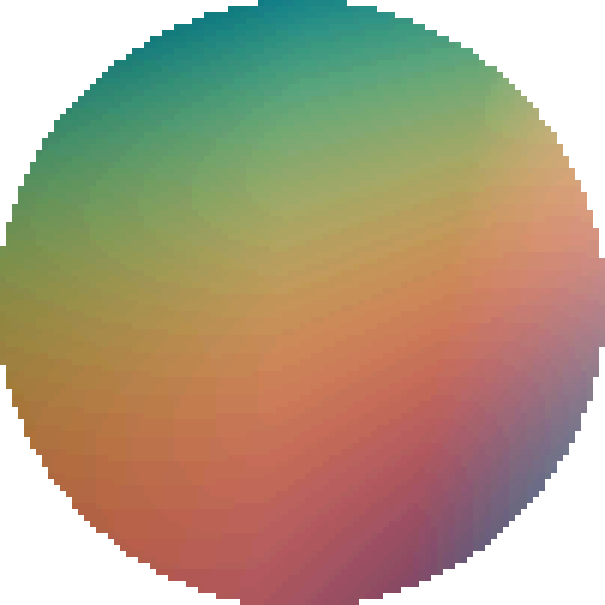

In [4]:
train_enhanced_images_R_list[5]


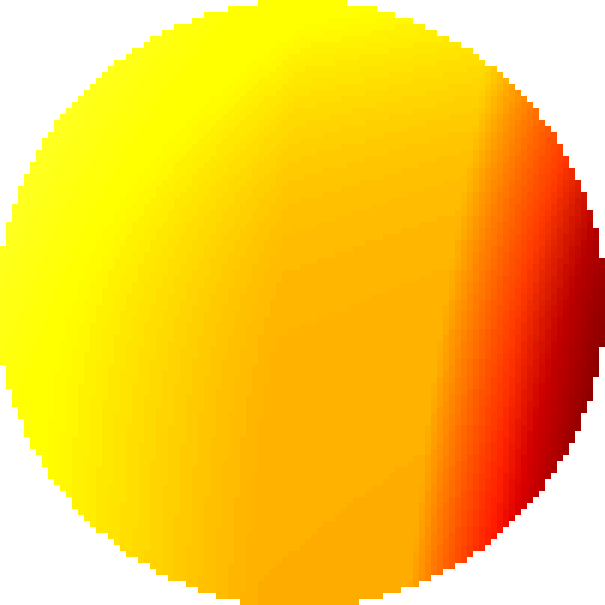

In [5]:
train_enhanced_images_T_list[5]

In [6]:
def plot_targets_on_simulated_image(df):
    # Determine the range of coordinates
    x_min, x_max = df['x'].min(), df['x'].max()
    y_min, y_max = df['y'].min(), df['y'].max()
    # print(x_min, x_max, y_min, y_max)
    
    # Create a blank white image based on the coordinate range
    img_width = int(x_max - x_min)
    img_height = int(y_max - y_min)
    img = Image.new('RGB', (img_width, img_height), 'white')
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the blank image
    ax.imshow(img, extent=[x_min, x_max, y_min, y_max], aspect='equal')

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        
        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Target {target}', 
                   s=10,
                   alpha=0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)
    
    # Create a mesh to plot the decision boundaries
    xx, yy = np.meshgrid(np.linspace(x_min - 1, x_max + 1, 100), np.linspace(y_min - 1, y_max + 1, 100))
    
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('"True" Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()


def plot_targets_on_real_image(df, img):

    img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])
    


    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        
        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Target {target}', 
                   s=10,
                   alpha = 0)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)
    
    # Create a mesh to plot the decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('True Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()


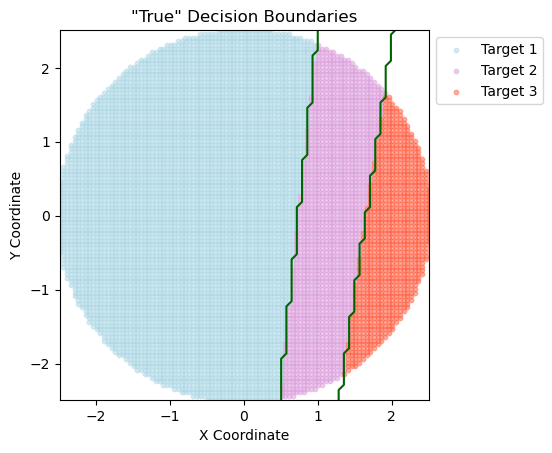

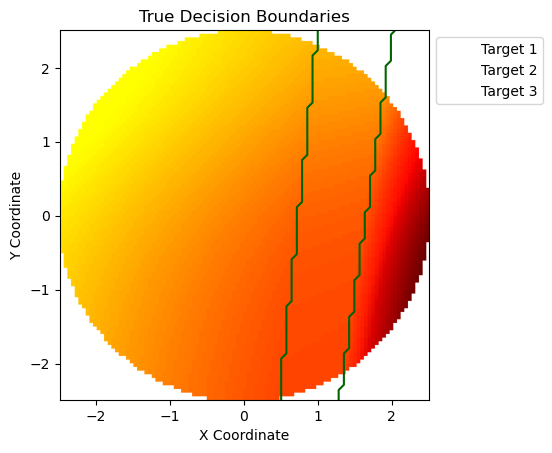

In [7]:
plot_targets_on_simulated_image(train_df_list[9])

plot_targets_on_real_image(train_df_list[9], train_enhanced_images_T_list[9]) 

In [8]:
print(train_df_list[0])
print(train_boundary_list)

         x     y            Sn            Ba         F  target
0    -2.49 -0.49  3.062847e-07  2.233571e-07  0.578287       2
1    -2.49 -0.44  3.053393e-07  2.225576e-07  0.578407       2
2    -2.49 -0.39  3.043868e-07  2.217501e-07  0.578532       2
3    -2.49 -0.34  3.034276e-07  2.209347e-07  0.578660       2
4    -2.49 -0.29  3.024617e-07  2.201116e-07  0.578793       2
...    ...   ...           ...           ...       ...     ...
8087  2.51  0.16  5.324942e-07  1.098397e-07  0.828999       3
8088  2.51  0.21  5.297602e-07  1.095386e-07  0.828658       3
8089  2.51  0.26  5.270208e-07  1.092346e-07  0.828316       3
8090  2.51  0.31  5.242763e-07  1.089279e-07  0.827973       3
8091  2.51  0.36  5.215273e-07  1.086184e-07  0.827630       3

[8092 rows x 6 columns]
[array([0.55, 0.76]), array([0.63, 0.75]), array([0.66, 0.75]), array([0.65, 0.69]), array([0.65, 0.69]), array([0.61, 0.69]), array([0.56, 0.71]), array([0.62, 0.77]), array([0.65, 0.7 ]), array([0.64, 0.69]), array([0

In [9]:
def plot_combined_targets_on_image(df, img):
    # img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'True Target {target}', 
                   s=10,
                   alpha = 0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the true target labels
    le_true = LabelEncoder()
    df['target_encoded_true'] = le_true.fit_transform(df['target'])

    # Fit logistic regression model for true targets
    X = df[['x', 'y']]
    y_true = df['target_encoded_true']
    model_true = LogisticRegression()
    model_true.fit(X, y_true)

    # Create a mesh to plot the true decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z_true = model_true.predict(grid_points)
    Z_true = Z_true.reshape(xx.shape)

    # Plot true decision boundaries
    ax.contour(xx, yy, Z_true, levels=[0.5, 1.5], colors=['darkgreen'], linestyles=['-'], label = 'True boundaries')
    

    # Encode the predicted target labels
    le_pred = LabelEncoder()
    df['target_encoded_pred'] = le_pred.fit_transform(df['target_pred'])

    # Fit logistic regression model for predicted targets
    y_pred = df['target_encoded_pred']
    model_pred = LogisticRegression()
    model_pred.fit(X, y_pred)

    # Create a mesh to plot the predicted decision boundaries
    Z_pred = model_pred.predict(grid_points)
    Z_pred = Z_pred.reshape(xx.shape)

    # Plot predicted decision boundaries
    ax.contour(xx, yy, Z_pred, levels=[0.5, 1.5], colors=['purple'], linestyles=['--'], label = 'Predict boundaries')

    # Add custom legend entries for boundaries
    handles, labels = ax.get_legend_handles_labels()
    handles.append(plt.Line2D([0], [0], color='darkgreen', linestyle='-', linewidth=2))
    labels.append('True Boundaries')
    handles.append(plt.Line2D([0], [0], color='purple', linestyle='--', linewidth=2))
    labels.append('Predicted Boundaries')
    
    ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1))
    
    
    # Show the plot
    plt.show()

In [10]:
# Assuming 'target' is the column in each DataFrame within train_df_list
train_target_list = [train_df_list[i]['target'].values for i in range(len(train_df_list))]

# Similarly for validation and test sets
val_target_list = [val_df_list[i]['target'].values for i in range(len(val_df_list))]
test_target_list = [test_df_list[i]['target'].values for i in range(len(test_df_list))]

In [34]:
train_df_list[1]

,x,y,Sn,Ba,F,target
0,-2.49,-0.49,2.466218e-07,1.847740e-07,0.571683,1
1,-2.49,-0.44,2.458337e-07,1.841126e-07,0.571778,1
2,-2.49,-0.39,2.450395e-07,1.834446e-07,0.571875,1
3,-2.49,-0.34,2.442391e-07,1.827701e-07,0.571976,1
4,-2.49,-0.29,2.434328e-07,1.820892e-07,0.572080,1
...,...,...,...,...,...,...
8087,2.51,0.16,4.403594e-07,9.086581e-08,0.828950,3
8088,2.51,0.21,4.379728e-07,9.061671e-08,0.828569,3
8089,2.51,0.26,4.355814e-07,9.036526e-08,0.828186,3
8090,2.51,0.31,4.331857e-07,9.011152e-08,0.827801,3


In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Concatenate, Reshape, TimeDistributed

# Shape of your images
image_height, image_width, image_channels = 605, 605, 3

# Combine the images along the channel dimension
def combine_images(img_list_T, img_list_R):
    combined = []
    for img_T, img_R in zip(img_list_T, img_list_R):
        combined.append(np.concatenate((img_T, img_R), axis=-1))
    return np.array(combined)

# Normalize the images
train_images_combined = combine_images(train_images_T_list, train_images_R_list) / 255.0
val_images_combined = combine_images(val_images_T_list, val_images_R_list) / 255.0
test_images_combined = combine_images(test_images_T_list, test_images_R_list) / 255.0

# Assuming target lists are already created
train_target_array_list = np.array(train_target_list)  # Shape: (number of samples, 8092)
val_target_array_list = np.array(val_target_list)      # Shape: (number of samples, 8092)
test_target_array_list = np.array(test_target_list)    # Shape: (number of samples, 8092)

# Define the input for the combined image set
input_combined = Input(shape=(image_height, image_width, 6), name='input_combined')

# Define a function to create the CNN layers
def create_cnn_layers(input_layer):
    x = Conv2D(32, (3, 3), activation='relu')(input_layer)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(256, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    return x

# Process the combined input through the CNN layers
x_combined = create_cnn_layers(input_combined)

# Add fully connected layers
fc = Dense(64, activation='relu')(x_combined)
fc = Dropout(0.5)(fc)
fc = Dense(8092 * 3, activation='relu')(fc)  # Intermediate layer with 8092 * 3 units
fc = Reshape((8092, 3))(fc)  # Reshape to (batch_size, 8092, 3)

output = TimeDistributed(Dense(3, activation='softmax'))(fc)  # Apply softmax to each time step

# Define the model
model = Model(inputs=input_combined, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_combined (InputLayer)     │ (None, 605, 605, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 603, 603, 32)   │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 301, 301, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 299, 299, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 149, 149, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 147, 147, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 73, 73, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1364224)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    87,310,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24276)          │     1,577,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8092, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 8092, 3)        │            12 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,222,272 (340.36 MB)

 Trainable params: 89,222,272 (340.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Adjust target labels to be zero-based
train_target_array_list = np.array(train_target_list) - 1  # Shape: (number of samples, 8092)
val_target_array_list = np.array(val_target_list) - 1      # Shape: (number of samples, 8092)
test_target_array_list = np.array(test_target_list) - 1    # Shape: (number of samples, 8092)

In [14]:
# Define learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Monitor validation loss
    factor=0.5,            # When the monitored metric stops improving, reduce learning rate by half
    patience=3,            # Number of epochs with no improvement before reducing learning rate
    min_lr=1e-6            # Minimum learning rate
)

In [15]:
history = model.fit(
    train_images_combined,  # Use the combined training images
    train_target_array_list,
    validation_data=(val_images_combined, val_target_array_list),  # Use the combined validation images
    epochs=60,
    batch_size=8,
    callbacks=[reduce_lr]
)

Epoch 1/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 476s 14s/step - accuracy: 0.3742 - loss: 1.2144 - val_accuracy: 0.4332 - val_loss: 1.0886 - learning_rate: 0.0010
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 115s 9s/step - accuracy: 0.3744 - loss: 1.0762 - val_accuracy: 0.4368 - val_loss: 1.0268 - learning_rate: 0.0010
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 111s 9s/step - accuracy: 0.3776 - loss: 1.0347 - val_accuracy: 0.5770 - val_loss: 0.8452 - learning_rate: 0.0010
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 114s 9s/step - accuracy: 0.5382 - loss: 0.8996 - val_accuracy: 0.6123 - val_loss: 0.7993 - learning_rate: 0.0010
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 128s 10s/step - accuracy: 0.6100 - loss: 0.8801 - val_accuracy: 0.6519 - val_loss: 0.7420 - learning_rate: 0.0010
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 119s 9s/step - accuracy: 0.6374 - loss: 0.8111 - val_accuracy: 0.6542 - val_loss: 0.7721 - learning_rate: 0.0010
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 113s 9s/step - accuracy: 0.6796 - loss: 0.7719 - val_a

In [16]:
# Make predictions on the combined test data (6 channels)
test_pred = model.predict(test_images_combined)

# Make prediction based on max probability
test_pred_labels = np.argmax(test_pred, axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 118s 52s/step


In [30]:
# Ensure the model's input signature is correct
test_loss, test_accuracy = model.evaluate(
    test_images_combined,  # Provide both inputs as a list
    test_target_array_list  # Provide target labels
)

# Print the test loss and test accuracy
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.8546 - loss: 0.4673
Test Loss: 0.46969178318977356
Test Accuracy: 85.57%


In [25]:
def plot_combined_targets_on_image_2(df, img):
    # img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'True Target {target}', 
                   s=10,
                   alpha = 0)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the true target labels
    le_true = LabelEncoder()
    df['target_encoded_true'] = le_true.fit_transform(df['target'])

    # Fit logistic regression model for true targets
    X = df[['x', 'y']]
    y_true = df['target_encoded_true']
    model_true = LogisticRegression()
    model_true.fit(X, y_true)

    # Create a mesh to plot the true decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z_true = model_true.predict(grid_points)
    Z_true = Z_true.reshape(xx.shape)

    # Plot true decision boundaries
    ax.contour(xx, yy, Z_true, levels=[0.5, 1.5], colors=['darkgreen'], linestyles=['-'], label = 'True boundaries')
    

        # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target_pred'] == target - 1]
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Predicted Target {target}', 
                   s=10,
                   alpha = 0.8)
    # Encode the predicted target labels
    

    # Add custom legend entries for boundaries
    handles, labels = ax.get_legend_handles_labels()
    handles.append(plt.Line2D([0], [0], color='darkgreen', linestyle='-', linewidth=2))
    labels.append('True Boundaries')

    
    ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1))
    
    
    # Show the plot
    plt.show()

In [ ]:
for i in range(50):
    test_df_list[i]['target_pred'] = test_pred_labels[i]

In [ ]:
for i in range(50):
    plot_combined_targets_on_image(test_df_list[i], test_enhanced_images_T_list[i]) 

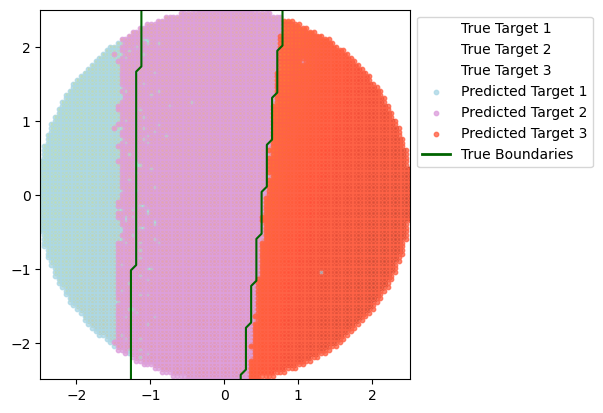

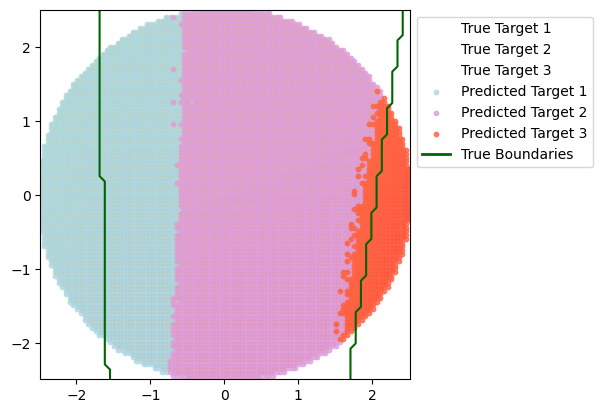

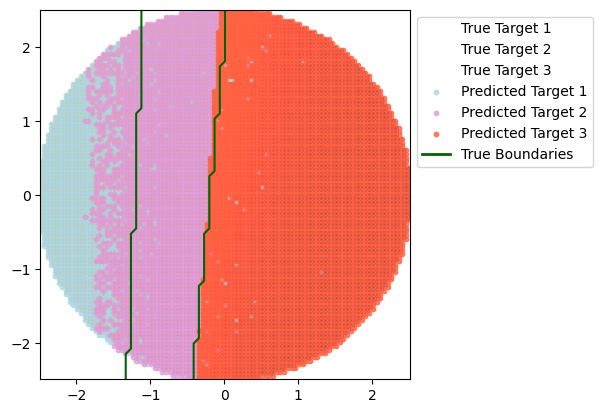

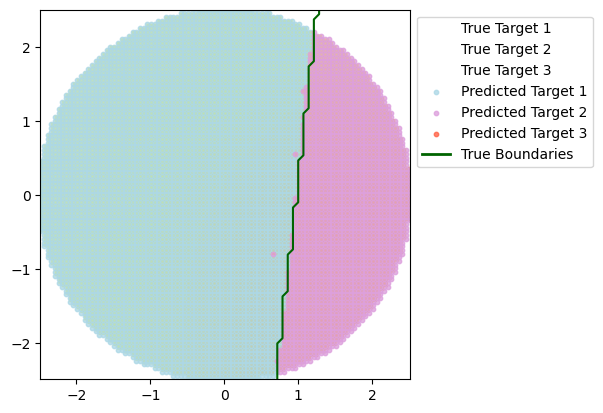

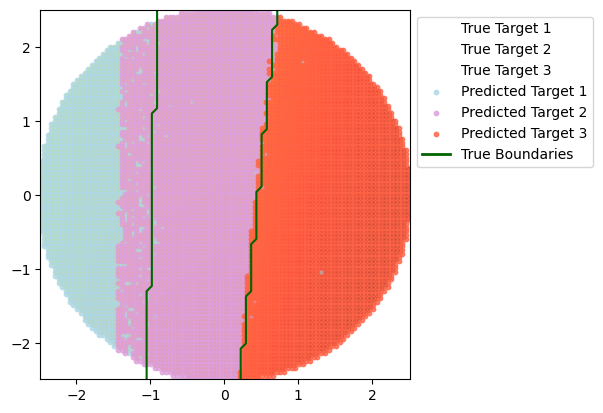

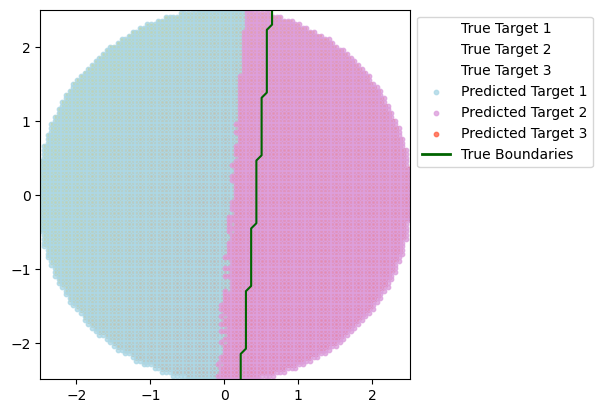

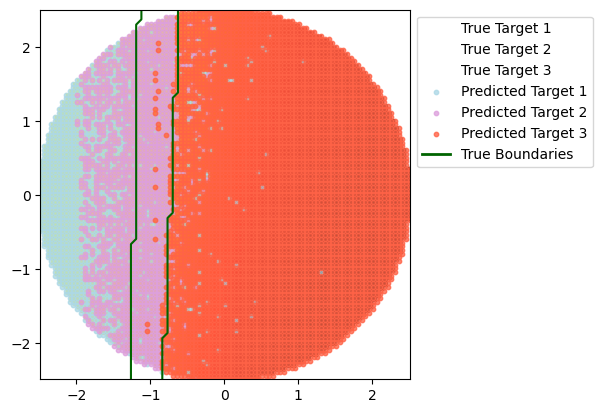

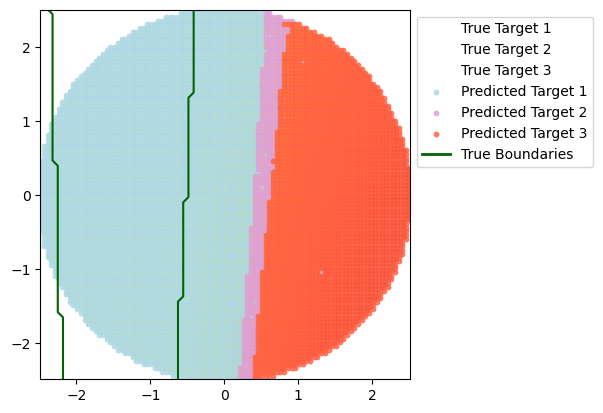

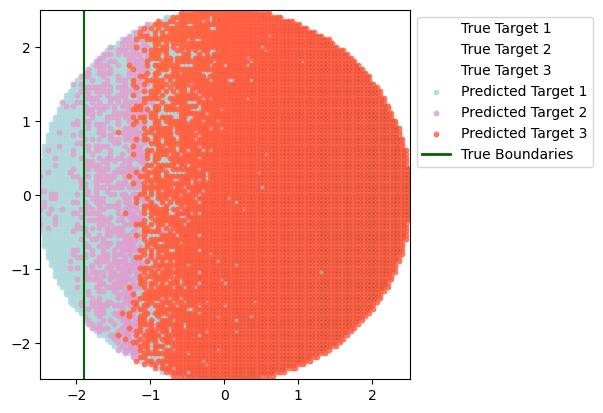

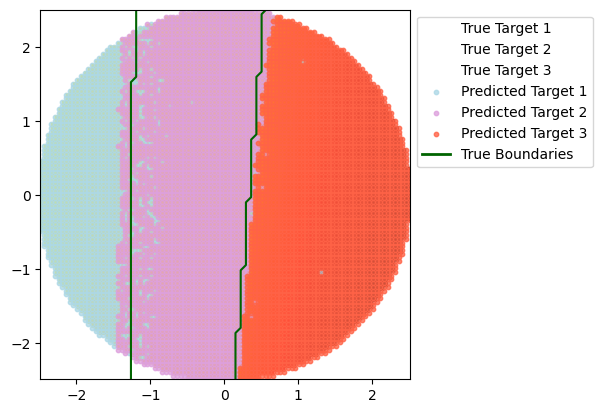

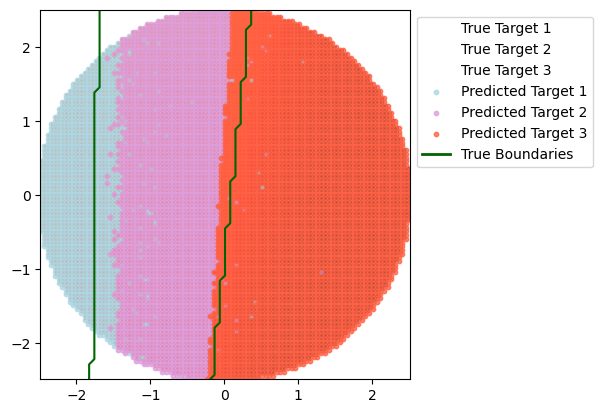

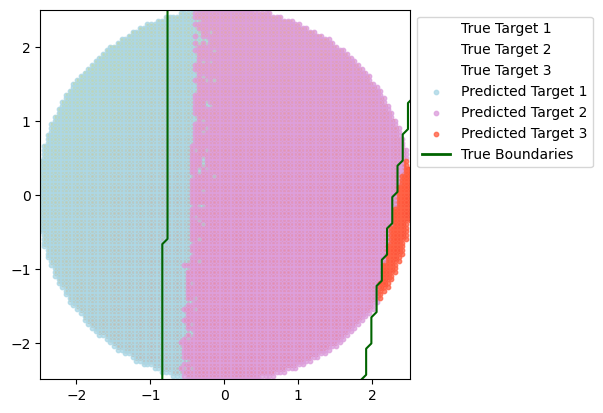

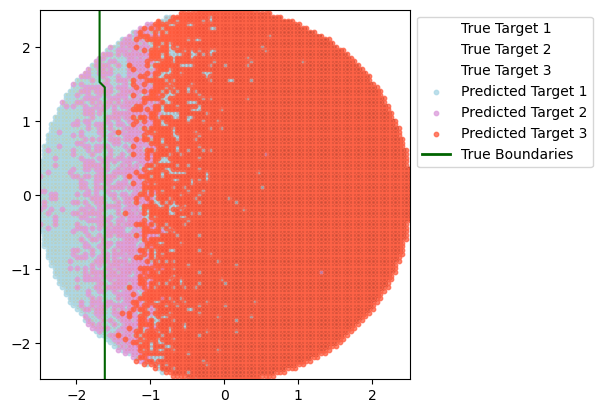

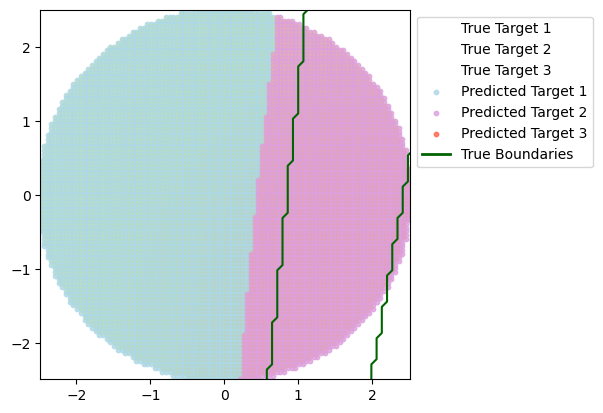

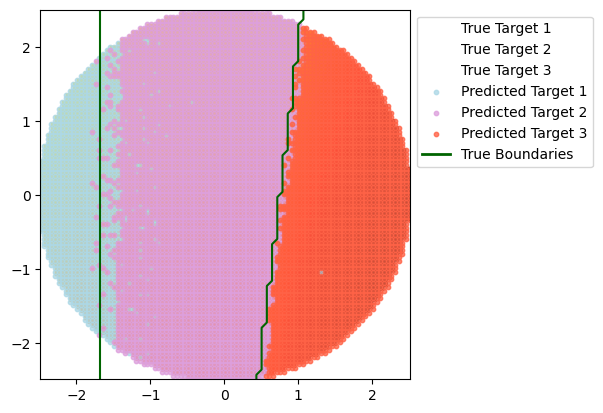

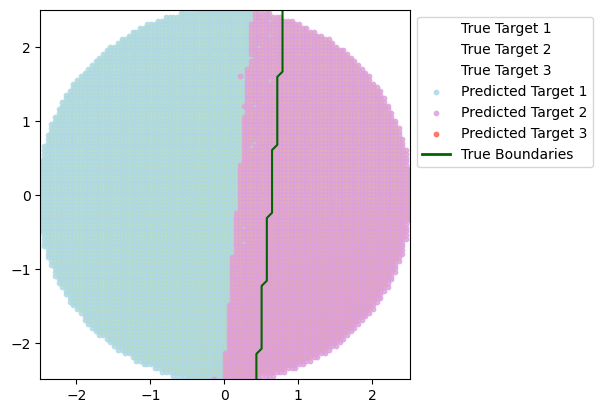

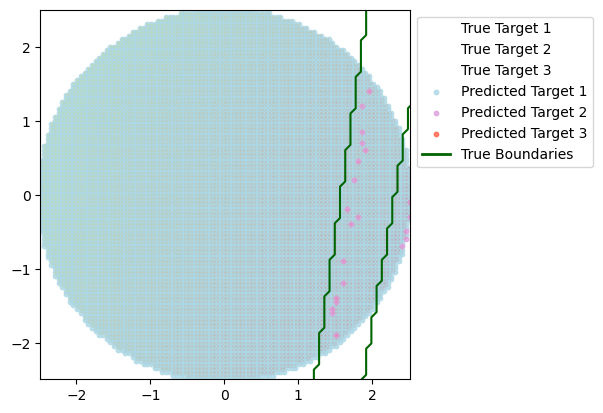

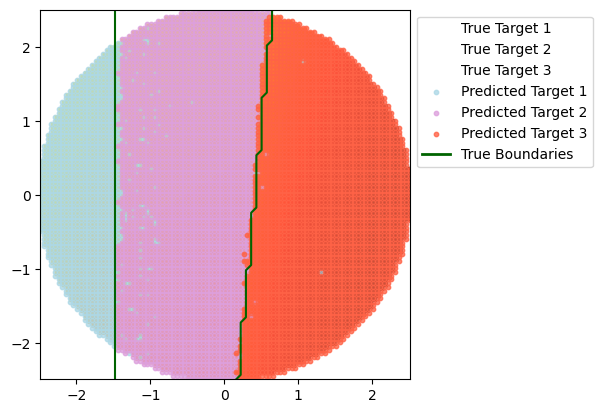

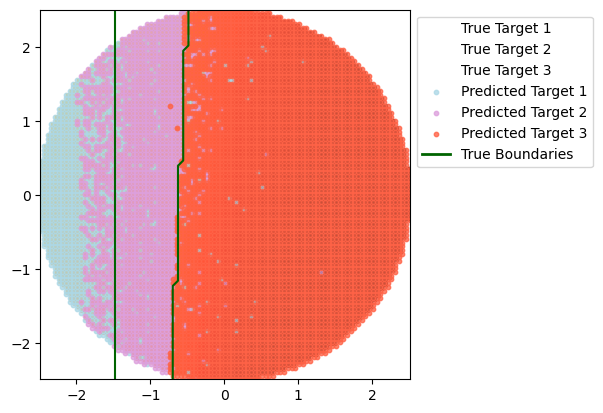

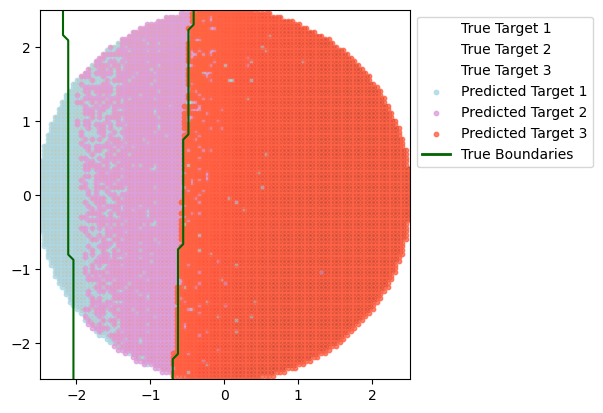

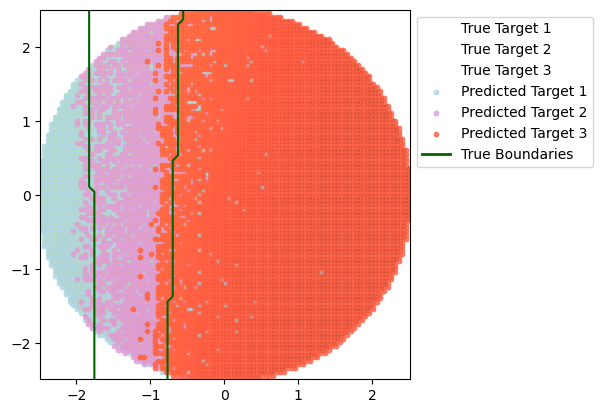

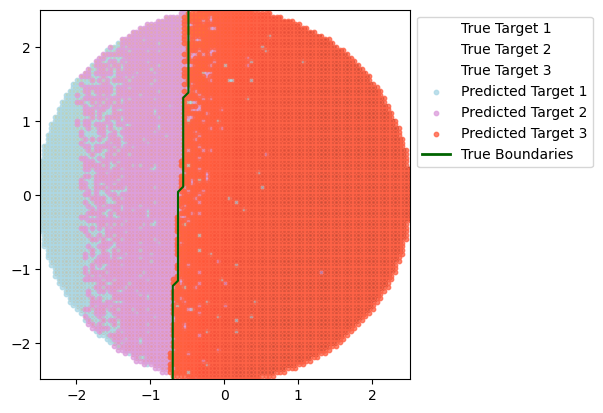

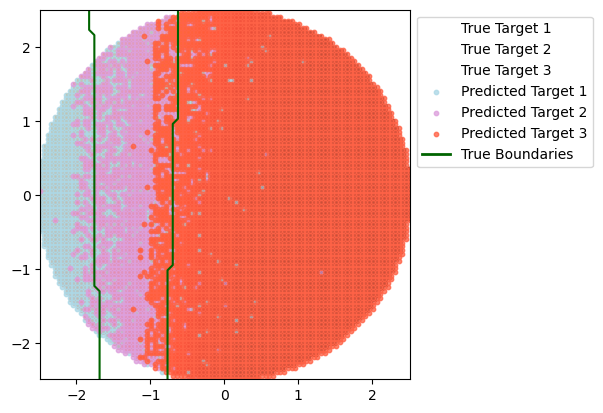

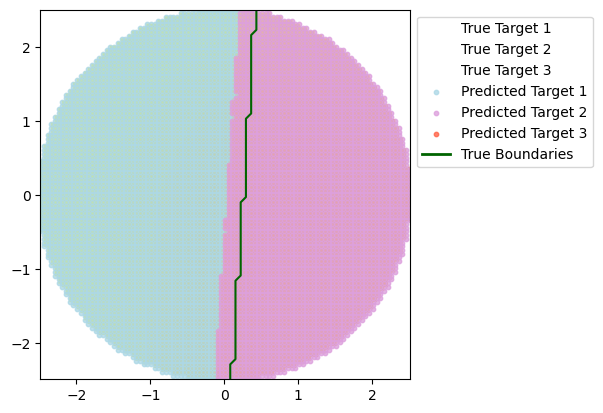

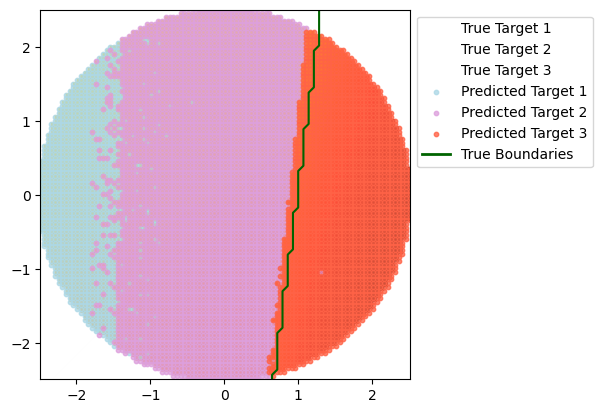

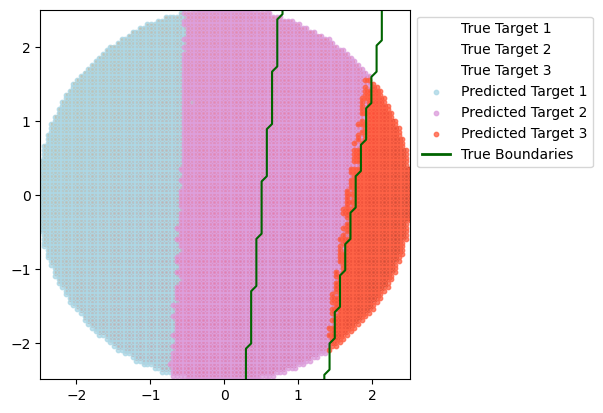

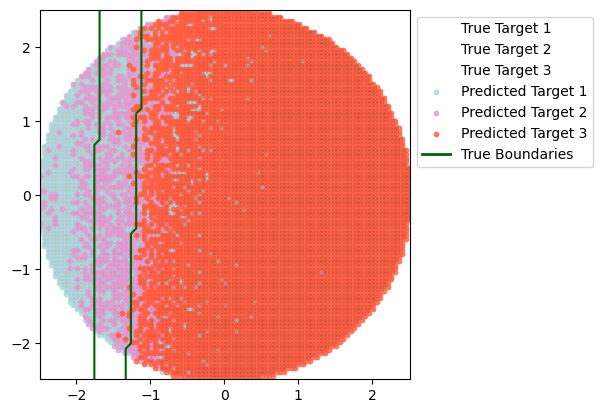

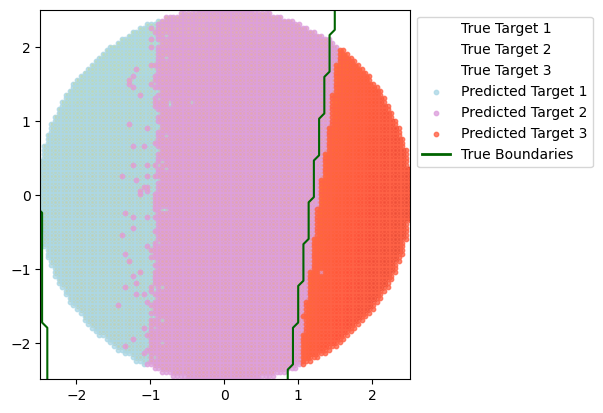

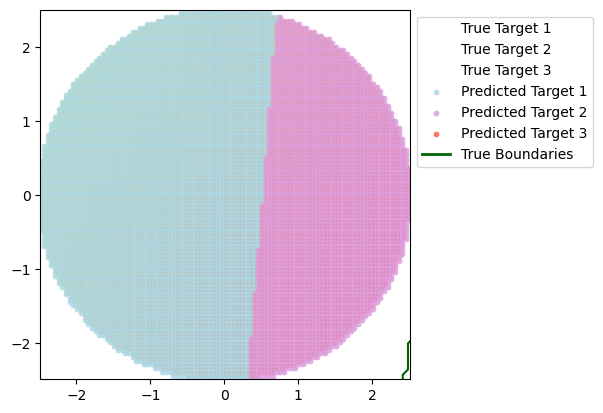

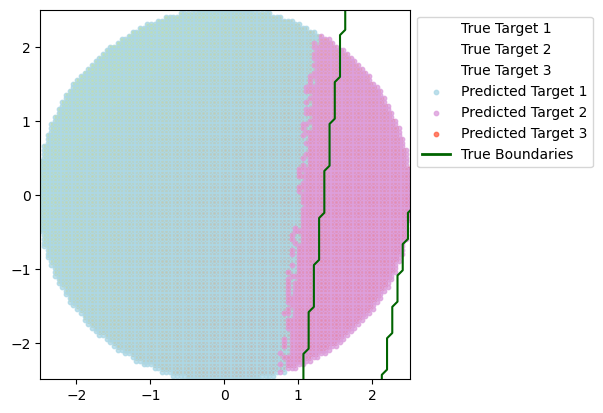

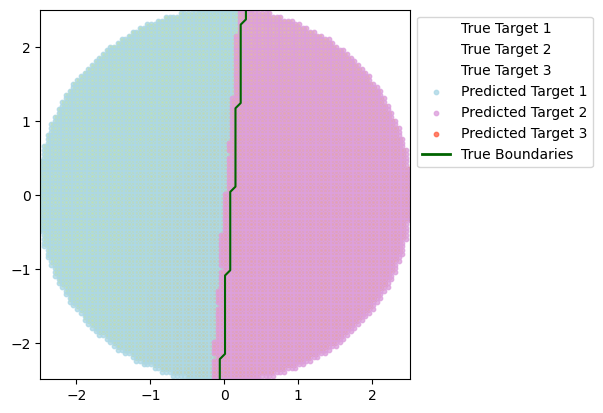

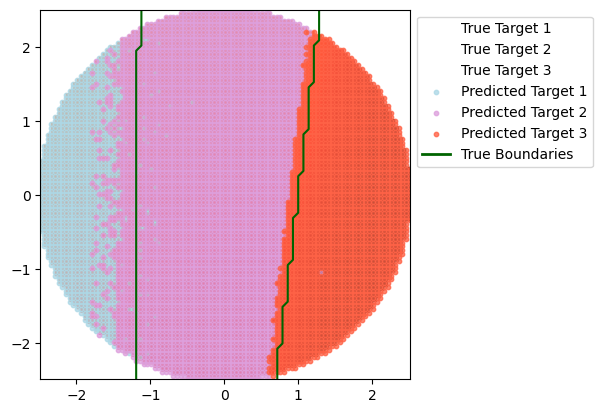

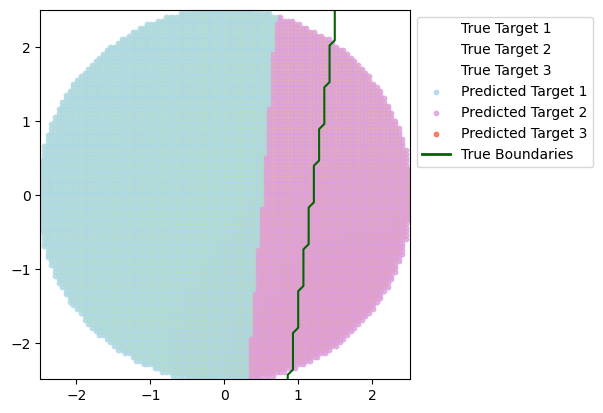

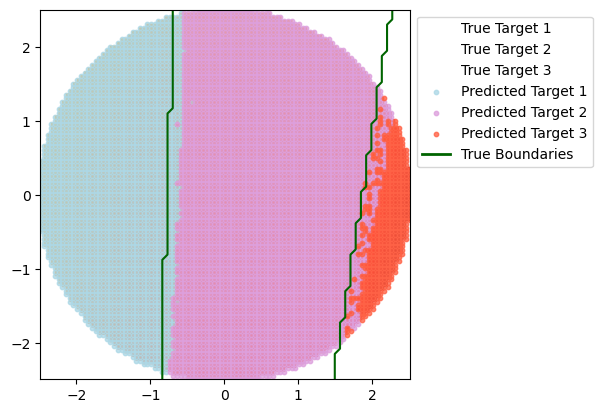

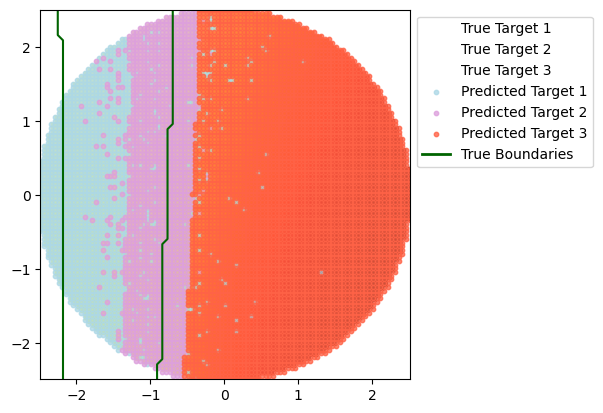

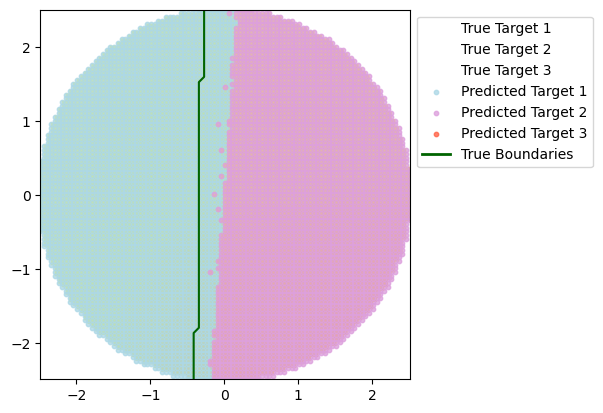

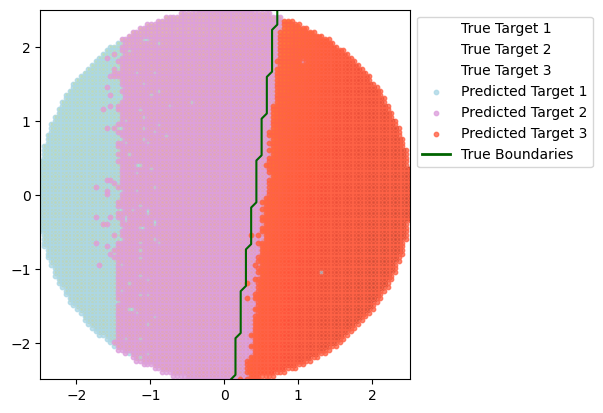

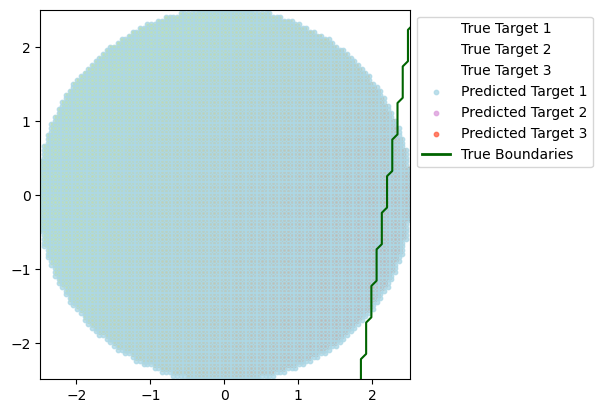

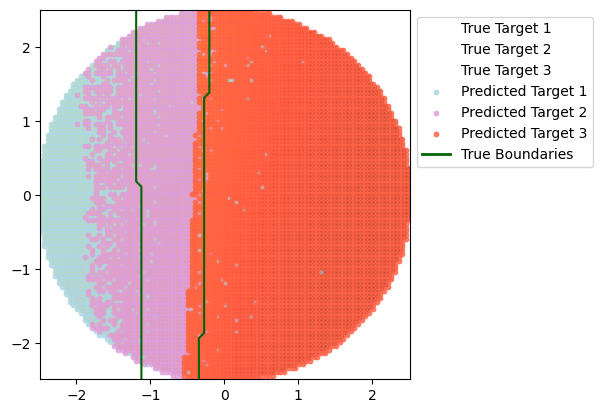

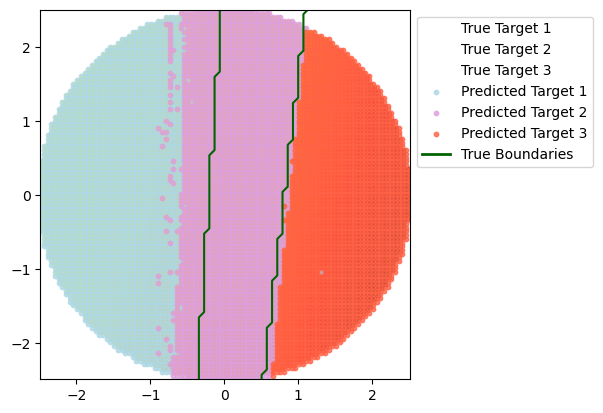

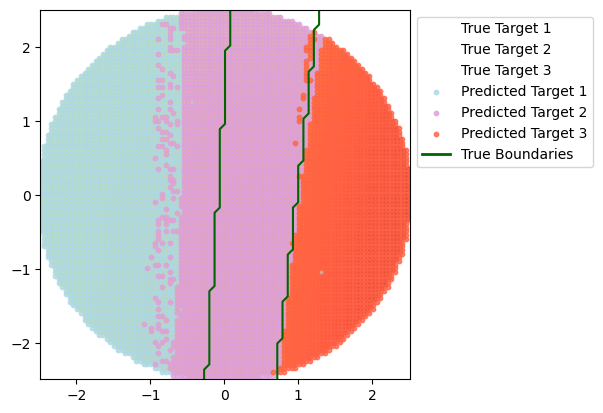

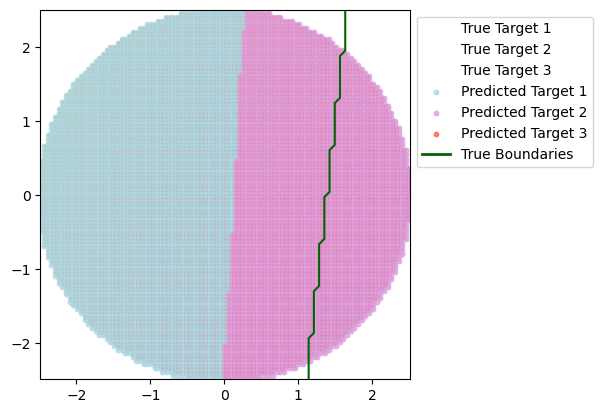

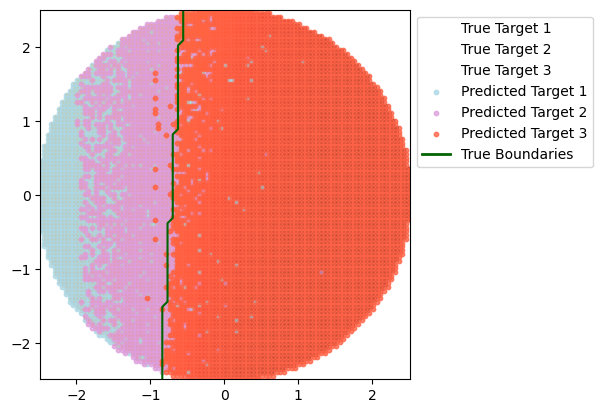

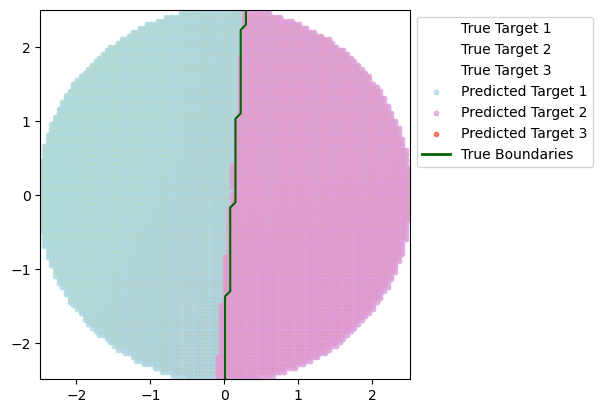

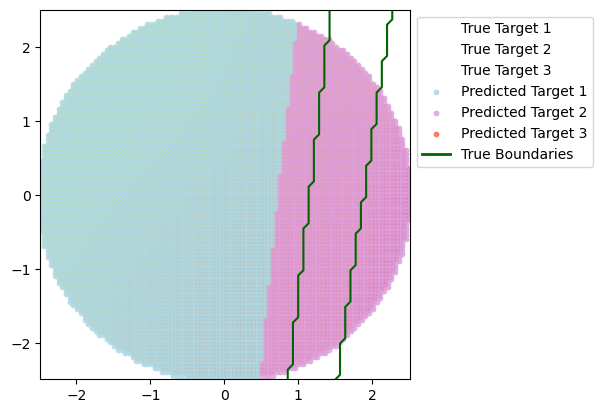

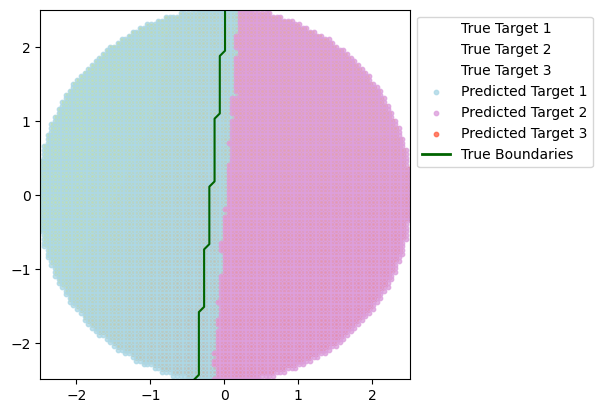

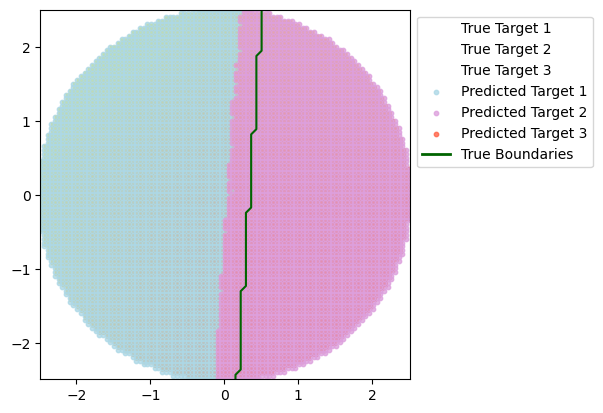

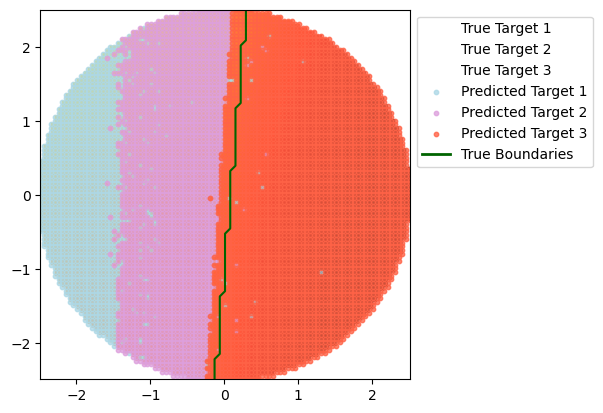

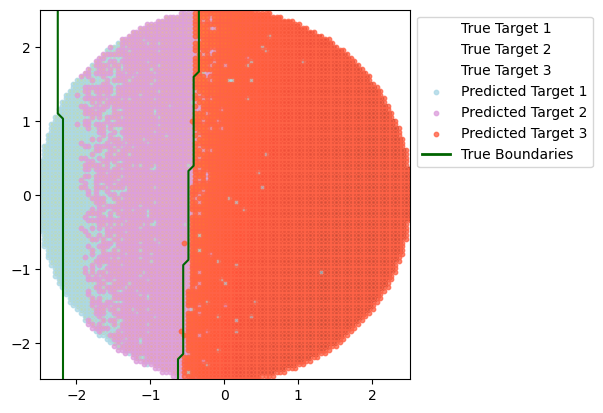

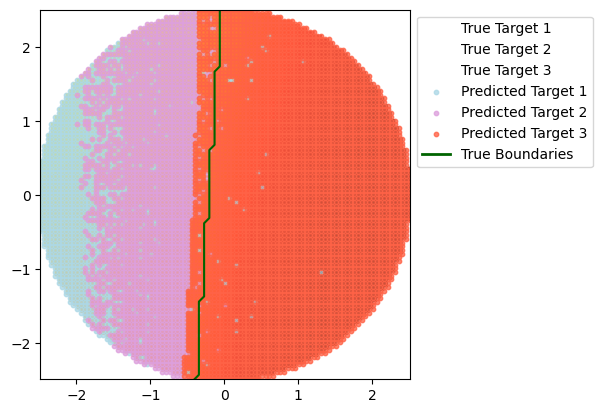

In [26]:
for i in range(50):
    plot_combined_targets_on_image_2(test_df_list[i], test_enhanced_images_T_list[i]) 